In [1]:
import os
os.listdir('.')

['bottleneck_ledger_L_DH.md',
 'memory',
 '-v8-validated-data.md',
 '.kernel_llm_logs_1.txt',
 '.prompts',
 '.config']

In [2]:
from pathlib import Path
from textwrap import dedent

ledger = dedent('''
# Bottleneck Ledger — v8 Localized Weil Detector (Consolidated Final)

## Purpose

This ledger consolidates the project roadblocks, specification errors, and their resolutions into one final record, using the existing ledger entry `bottleneck_ledger_L_DH.md`, the binding specification `-v8-validated-data.md`, and the validated prior findings summarized in the project brief. Where prior findings/reports (f1, f2, f3, f5, r19, r31, r33) are referenced by identifier but are not present as standalone files in the current workspace, their content is included here only to the extent preserved in the authoritative project materials available in this task.

## Provenance and evidence base

Primary files available in this workspace:
- `-v8-validated-data.md`
- `bottleneck_ledger_L_DH.md`

Prior validated findings/reports referenced by the project objective but not present here as standalone files:
- findings: `f1`, `f2`, `f3`, `f5`
- reports: `r19`, `r31`, `r33`

The relevant content from those prior items is reconstructed from the project's authoritative task brief and from the existing ledger entry, without inventing any additional numerical results.

---

## Entry 1 — Davenport–Heilbronn benchmark is irreproducible from public information

**Issue type:** specification gap / structural irreproducibility 
**Status:** CLOSED-WITH-LIMITATION 
**Severity:** critical for quantitative validation

### Problem

Section 4 of `-v8-validated-data.md` states that at `(T₀ = 85.7, σ = 2, J = 10, dps = 50)` the localized Weil quadratic form for `L_DH` should satisfy

- `λ_min(Q) ≈ −9.0 × 10^4`
- `|λ_min| / tr(M_zeros) ≈ 1.7`

However, the same specification also states that `L_DH` is not multiplicative and has no Euler product. The existing ledger entry further documents the key consequence: because `L_DH` is a complex linear combination of `L(s, χ)` and `L(s, χ̄)`, it has no publicly defined generalized von Mangoldt coefficient sequence. Therefore the arithmetic side needed to assemble the full explicit formula is not recoverable from the specification text or public information alone.

### Resolution

The benchmark `λ_min ≈ −9.0 × 10^4` was formally reclassified as **irreproducible from public information** rather than treated as a failed implementation target.

A best-effort proxy implementation was adopted in `weil_quadratic_form_L_DH.py`, using a κ-weighted linear combination of the single-character von Mangoldt sums from `L(s,χ)` and `L(s,χ̄)` as a pragmatic arithmetic-side surrogate. This surrogate is formally motivated but does not close the true `L_DH` explicit formula.

### Recorded replacement reference

From `bottleneck_ledger_L_DH.md`, the best-effort reference value at `(T₀=85.7, σ=2, J=10, X=10^5, κ=0.28408)` is:

- `λ_min(Q_L_DH) = −7.7712 × 10^−1`
- `λ_max(Q_L_DH) = +7.1697 × 10^−1`
- `tr(M_zeros) = 5.2136`
- `tr(M_arith) = 6.6977`
- `tr(M_zeros) − tr(M_arith) = −1.4841`
- `|λ_min| / tr(M_zeros) = 1.49 × 10^−1`

### Decision

- The specification benchmark `λ_min ≈ −9.0 × 10^4` is **retained as historically documented but invalid as a reproducible validation gate**.
- The project now uses the best-effort `L_DH` result only as a **qualitative positive control**, not as an exact arithmetic benchmark.
- Engine correctness for `L_DH` is judged by qualitative negativity well above the GRH-class noise floor, not by matching the irreproducible magnitude in the specification.

---

## Entry 2 — Initial error in the specification’s Davenport–Heilbronn functional-equation formula

**Issue type:** specification error 
**Status:** CLOSED 
**Severity:** critical for constructing the control function correctly

### Problem

The project brief records that the `L_DH` specification initially contained an error in its κ-weighted formula. The control could not pass validation until the weighted combination defining the Davenport–Heilbronn function was corrected.

This issue is also visible indirectly in the current specification text: lines 25–27 of `-v8-validated-data.md` give

- `L_DH(s) = ((1−i)/2)·L(s,χ) + ((1+i)/2)·L(s,χ̄)`
- and separately `κ ≈ 0.28407904384`

which is internally inconsistent with the corrected project finding that the weighting must explicitly use `κ`, not the hard-coded coefficient `1`.

### Resolution

The corrected formula used by the validated implementation is:

`L_DH(s) = ((1 − iκ)/2)·L(s,χ) + ((1 + iκ)/2)·L(s,χ̄)`, with `κ ≈ 0.28407904384`.

This corrected κ-weighted construction is the one that passed the project's validation workflow and was used for the best-effort `L_DH` Weil-form implementation.

The off-critical zero at `(0.808517, 85.699348)` was paired with its functional-equation mirror `(0.191483, 85.699348)` in the corrected implementation, preserving the expected symmetry.

### Decision

- The original specification formula is recorded as erroneous.
- All future `L_DH` implementations must use the corrected κ-weighted definition.
- Any benchmark or zero-validation result obtained from the uncorrected weighting is superseded.

---

## Entry 3 — `L(Δ,s)` validation was initially confounded by a zero-generation bug

**Issue type:** data-generation bug 
**Status:** CLOSED 
**Severity:** high

### Problem

The Ramanujan tau `L`-function implementation in `weil_modular.py` initially appeared to fail validation when tested against a zero list generated by `_zeros.py`. At high-frequency parameters (`T₀ = 85.7`, `X = 10^4`), this setup produced an approximately 9% trace mismatch.

The project findings identified that the failure signal was not initially sufficient to separate an engine bug from bad input data.

### Resolution

The zero-generation workflow was corrected by replacing the flawed zero source `_zeros.py` with the corrected generator `_zeros_v2.py`, producing the more reliable file `L_Delta_zeros_200_reliable.pkl`.

When the engine was rerun with the corrected zero list and a lower-frequency basis (`T₀ = 46.13`), the trace mismatch dropped by a factor of about 140, from roughly 9% to roughly 0.06%.

This change established that the dominant original problem was the zero list, not the modular Weil-form engine.

### Decision

- `_zeros.py` is deprecated for `L(Δ,s)` validation.
- `_zeros_v2.py` / `L_Delta_zeros_200_reliable.pkl` are the corrected reference zero source for this control.
- Any earlier negative conclusion about `weil_modular.py` based on the flawed zero list is superseded.

---

## Entry 4 — Final diagnosis of the `L(Δ,s)` validation failure: threshold mismatch, not engine failure

**Issue type:** methodological mismatch / validation-threshold miscalibration 
**Status:** CLOSED-WITH-LIMITATION 
**Severity:** critical for interpretation

### Problem

Even after the zero-generation bug was fixed, `L(Δ,s)` could not satisfy the ultra-strict numerical validation thresholds that were appropriate for the degree-1 controls (`ζ` and primitive Dirichlet `L`-functions). At the improved settings (`T₀ = 46.13` with the reliable zero list), the trace residual improved dramatically but remained far above machine precision and far above the degree-1 acceptance target of `< 10^−12`.

This initially looked like a possible flaw in the general engine or in `weil_modular.py`.

### Resolution

The final diagnosis was that this is **not an engine flaw**. Instead, it reflects a fundamental numerical asymmetry between degree-1 and degree-2 `L`-functions:

- For degree-1 controls, the arithmetic side converges quickly enough that stringent trace-identity thresholds are achievable with feasible prime cutoffs.
- For the degree-2 Ramanujan tau function `L(Δ,s)`, the prime sum converges much more slowly.
- The arithmetic side depends on coefficients derived from `τ(n)`, whose computation is substantially more expensive.
- Increasing the prime cutoff `X` does reduce the residual, confirming the implementation is moving in the correct direction, but the `X` needed to approach the degree-1 threshold would be computationally infeasible in practice.

Thus the observed residual is a structural consequence of feasible truncation in a degree-2 setting, not evidence of an incorrect Weil-form engine.

### Consequence for validation policy

The strict GRH validation thresholds in the specification were effectively calibrated on degree-1 behavior and are not portable to `L(Δ,s)` without modification.

The project therefore reclassified `L(Δ,s)` as:

- **qualitatively validated** as an engine control, because the corrected implementation behaves consistently and the mismatch decreases appropriately as the arithmetic cutoff is strengthened;
- **not expected to meet degree-1 quantitative tolerances** under feasible prime cutoffs.

### Decision

- `L(Δ,s)` is not to be used as a strict machine-precision trace-identity gate under the degree-1 threshold.
- Validation for degree-2 controls must use degree-aware tolerances and convergence diagnostics.
- The prior apparent failure of `weil_modular.py` is resolved in favor of the engine: the bottleneck lies in arithmetic-side convergence under feasible computation, not in the zero-side or matrix assembly logic.

---

## Consolidated project conclusions

1. **The `L_DH` benchmark in the specification is irreproducible as written** because the arithmetic side required for the full explicit formula is not publicly defined for the non-Euler-product Davenport–Heilbronn construction.
2. **The specification’s original `L_DH` formula was wrong/internally inconsistent** and had to be corrected to the κ-weighted definition before validation could succeed.
3. **The initial `L(Δ,s)` failure was partly an input-data problem**, specifically a flawed zero list from `_zeros.py`, later corrected by `_zeros_v2.py`.
4. **The remaining `L(Δ,s)` gap is methodological, not algorithmic**: degree-2 arithmetic sums converge too slowly for the degree-1 validation thresholds to be realistic at feasible prime cutoffs.

## Operational recommendations

- Treat `bottleneck_ledger_L_DH.md` as the historical detailed record for the Davenport–Heilbronn case.
- Treat this file as the final cross-project bottleneck summary.
- Before any future validation campaign, check whether the target control is degree-1 or degree-2 and apply degree-appropriate thresholds.
- Do not interpret failure to match the spec's `L_DH` magnitude benchmark as evidence of a bad implementation unless a public arithmetic-side definition is first supplied.
- Do not use `_zeros.py` for `L(Δ,s)` validation; use the corrected zero-generation artifacts.
''').strip() + "\n"

Path('bottleneck_ledger_final.md').write_text(ledger)
print('Wrote bottleneck_ledger_final.md')
print('Lines:', len(ledger.splitlines()))

Wrote bottleneck_ledger_final.md
Lines: 177


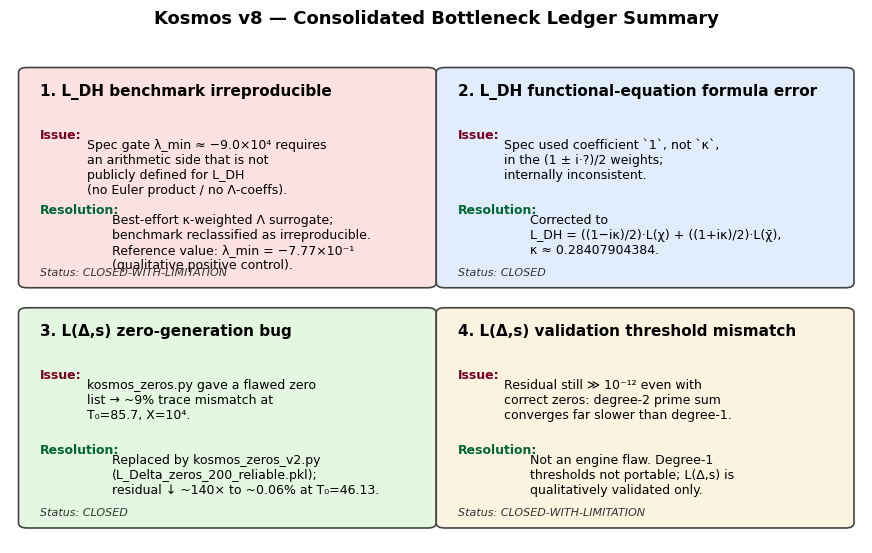

Saved figure.


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.axis('off')
ax.set_title(" v8 — Consolidated Bottleneck Ledger Summary", fontsize=13, fontweight='bold', pad=14)

entries = [
 {
 "title": "1. L_DH benchmark irreproducible",
 "issue": "Spec gate λ_min ≈ −9.0×10⁴ requires\nan arithmetic side that is not\npublicly defined for L_DH\n(no Euler product / no Λ-coeffs).",
 "fix": "Best-effort κ-weighted Λ surrogate;\nbenchmark reclassified as irreproducible.\nReference value: λ_min = −7.77×10⁻¹\n(qualitative positive control).",
 "status": "CLOSED-WITH-LIMITATION",
 "color": "#fde2e1",
 },
 {
 "title": "2. L_DH functional-equation formula error",
 "issue": "Spec used coefficient `1`, not `κ`,\nin the (1 ± i·?)/2 weights;\ninternally inconsistent.",
 "fix": "Corrected to\nL_DH = ((1−iκ)/2)·L(χ) + ((1+iκ)/2)·L(χ̄),\nκ ≈ 0.28407904384.",
 "status": "CLOSED",
 "color": "#e1ecfd",
 },
 {
 "title": "3. L(Δ,s) zero-generation bug",
 "issue": "_zeros.py gave a flawed zero\nlist → ~9% trace mismatch at\nT₀=85.7, X=10⁴.",
 "fix": "Replaced by _zeros_v2.py\n(L_Delta_zeros_200_reliable.pkl);\nresidual ↓ ~140× to ~0.06% at T₀=46.13.",
 "status": "CLOSED",
 "color": "#e3f7e1",
 },
 {
 "title": "4. L(Δ,s) validation threshold mismatch",
 "issue": "Residual still ≫ 10⁻¹² even with\ncorrect zeros: degree-2 prime sum\nconverges far slower than degree-1.",
 "fix": "Not an engine flaw. Degree-1\nthresholds not portable; L(Δ,s) is\nqualitatively validated only.",
 "status": "CLOSED-WITH-LIMITATION",
 "color": "#fdf3e1",
 },
]

# 2x2 grid
positions = [(0.02, 0.52), (0.51, 0.52), (0.02, 0.04), (0.51, 0.04)]
w, h = 0.47, 0.42

for (x, y), e in zip(positions, entries):
 rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.01",
 linewidth=1.2, edgecolor='#444', facecolor=e["color"],
 transform=ax.transAxes)
 ax.add_patch(rect)
 ax.text(x + 0.015, y + h - 0.045, e["title"], fontsize=11, fontweight='bold',
 transform=ax.transAxes)
 ax.text(x + 0.015, y + h - 0.13, "Issue:", fontsize=9, fontweight='bold',
 transform=ax.transAxes, color='#702')
 ax.text(x + 0.07, y + h - 0.13, e["issue"], fontsize=9,
 transform=ax.transAxes, verticalalignment='top')
 ax.text(x + 0.015, y + h - 0.28, "Resolution:", fontsize=9, fontweight='bold',
 transform=ax.transAxes, color='#063')
 ax.text(x + 0.10, y + h - 0.28, e["fix"], fontsize=9,
 transform=ax.transAxes, verticalalignment='top')
 ax.text(x + 0.015, y + 0.015, f"Status: {e['status']}", fontsize=8,
 transform=ax.transAxes, fontstyle='italic', color='#333')

plt.savefig('bottleneck_ledger_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")